**Python implementation of Parameter Estimation code, base paper "WyNDA"**

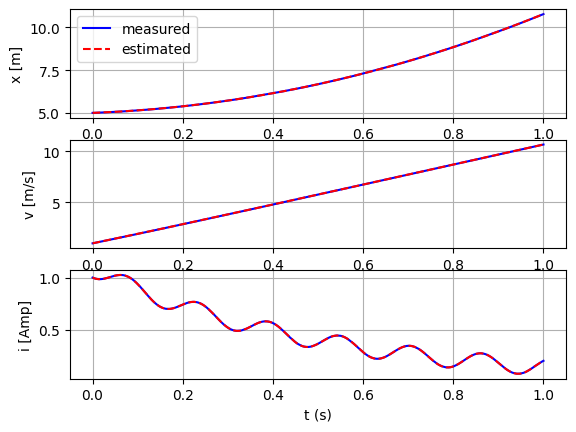

C:\Users\USER\AppData\Local\Temp\ipykernel_10056\535822171.py:139: RuntimeWarning: divide by zero encountered in divide
  axs[0,0].plot(t, dt/thetabarArray[4],'g--')
C:\Users\USER\AppData\Local\Temp\ipykernel_10056\535822171.py:144: RuntimeWarning: divide by zero encountered in divide
  axs[0,1].plot(t, L - (dt/thetabarArray[4]),'r--')


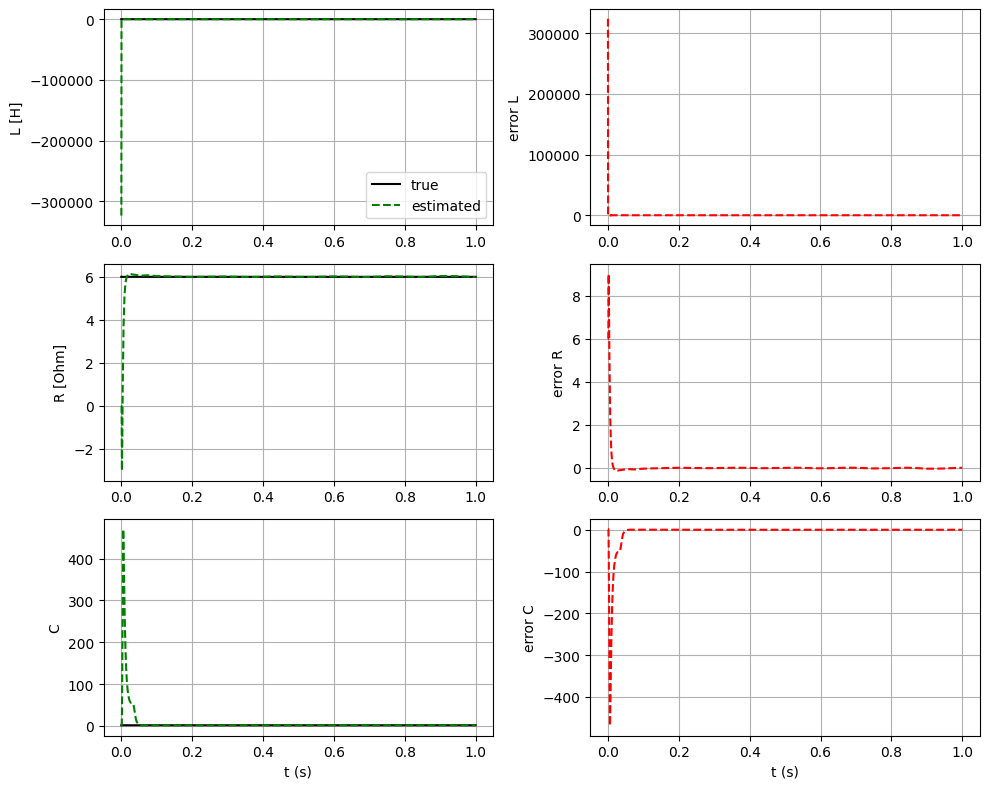

Estimated coefficients:
[  1.00000072   9.80010791 -15.06212738  -1.99888369   0.3334993 ]


C:\Users\USER\AppData\Local\Temp\ipykernel_10056\535822171.py:177: RuntimeWarning: divide by zero encountered in divide
  Lbar = dt / thetabarArray[4]
C:\Users\USER\AppData\Local\Temp\ipykernel_10056\535822171.py:178: RuntimeWarning: invalid value encountered in multiply
  Rbar = -Lbar * thetabarArray[3] / dt


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# time horizon
tf = 1
dt = 0.0001
t = np.arange(dt, tf + dt, dt)

# system size
n = 3
r = 5

# noise
RF = 1

# initial states
x = np.array([5.0, 1.0, 1.0])
xbar = x.copy()
y = x.copy()

thetabar = np.zeros(r)


# true parameters
g = 9.8
c = 1.5
m = 0.1
R = 6
L = 3

# control input
u = 2

# storage analysis
uArray = []
xArray = []
xbarArray = []
yArray = []
thetabarArray = []

# estimator initialization
lambdav = 0.995
lambdat = 0.999

Rx = np.eye(n)
Rt = np.eye(n)

Px = 10000 * np.eye(n)
Pt = 10000 * np.eye(r)

Gamma = np.zeros((n, r))


# simulation
for i in range(int(tf/dt)):

    u = 10 * np.sin(i * dt * 40)

    uArray.append(u)
    xArray.append(x.copy())
    xbarArray.append(xbar.copy())
    yArray.append(y.copy())
    thetabarArray.append(thetabar.copy())

    # system dynamics
    dx = np.array([
        x[1],
        g - (c/m) * (x[2]/x[0])**2,
        -(R/L) * x[2]
    ])

    B = np.array([0, 0, 1/L])
    x = x + dt * dx + dt * B * u
    y = x + dt*(RF**2)*np.random.randn(n)

    # Phi matrix
    Phi = np.array([
        [y[1], 0, 0, 0, 0],
        [0, 1, (y[2]/y[0])**2, 0, 0],
        [0, 0, 0, y[2], u]
    ])

    # adaptive observer
    Kx = Px @ np.linalg.inv(Px + Rx)
    Kt = Pt @ Gamma.T @ np.linalg.inv(Gamma @ Pt @ Gamma.T + Rt)

    Gamma = (np.eye(n) - Kx) @ Gamma

    xbar = xbar + (Kx + Gamma @ Kt) @ (y - xbar)
    thetabar = thetabar - Kt @ (y - xbar)

    xbar = xbar + Phi @ thetabar

    Px = (1/lambdav) * (np.eye(n) - Kx) @ Px
    Pt = (1/lambdat) * (np.eye(r) - Kt @ Gamma) @ Pt

    Gamma = Gamma - Phi


# convert arrays
xArray = np.array(xArray).T
xbarArray = np.array(xbarArray).T
yArray = np.array(yArray).T
uArray = np.array(uArray)
thetabarArray = np.array(thetabarArray).T


# states
plt.figure()

plt.subplot(3,1,1)
plt.plot(t, yArray[0], 'b')
plt.plot(t, xbarArray[0], 'r--')
plt.ylabel("x [m]")
plt.legend(["measured","estimated"])
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, yArray[1], 'b')
plt.plot(t, xbarArray[1], 'r--')
plt.ylabel("v [m/s]")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, yArray[2], 'b')
plt.plot(t, xbarArray[2], 'r--')
plt.ylabel("i [Amp]")
plt.xlabel("t (s)")
plt.grid(True)

plt.show()


# parameter estimation
fig, axs = plt.subplots(3,2, figsize=(10,8))

# L
axs[0,0].plot(t, L*np.ones_like(t),'k')
axs[0,0].plot(t, dt/thetabarArray[4],'g--')
axs[0,0].set_ylabel("L [H]")
axs[0,0].legend(["true","estimated"])
axs[0,0].grid(True)

axs[0,1].plot(t, L - (dt/thetabarArray[4]),'r--')
axs[0,1].set_ylabel("error L")
axs[0,1].grid(True)

# R
axs[1,0].plot(t, R*np.ones_like(t),'k')
axs[1,0].plot(t, -L*thetabarArray[3]/dt,'g--')
axs[1,0].set_ylabel("R [Ohm]")
axs[1,0].grid(True)

axs[1,1].plot(t, R + L*thetabarArray[3]/dt,'r--')
axs[1,1].set_ylabel("error R")
axs[1,1].grid(True)

# C
axs[2,0].plot(t, c*np.ones_like(t),'k')
axs[2,0].plot(t, -m*thetabarArray[2]/dt,'g--')
axs[2,0].set_ylabel("C")
axs[2,0].set_xlabel("t (s)")
axs[2,0].grid(True)

axs[2,1].plot(t, c + m*thetabarArray[2]/dt,'r--')
axs[2,1].set_ylabel("error C")
axs[2,1].set_xlabel("t (s)")
axs[2,1].grid(True)

plt.tight_layout()
plt.show()


# coefficient estimates
Coeff = (1/dt) * thetabar

Lbar = dt / thetabarArray[4]
Rbar = -Lbar * thetabarArray[3] / dt
Cbar = -m * thetabarArray[2] / dt

print("Estimated coefficients:")
print(Coeff)
